In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path
import re
import plotly.express as px
import plotly.graph_objects as go
from collections import defaultdict

mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

EDTA = Path('/hpcfs/users/a1864358/sanders_lab/asm/files/repeat-anno')
OUTDIR = Path('/scratchdata1/users/a1864358/sanders_lab/asm/files/repeat-anno/ra2/plots')
OUTDIR.mkdir(exist_ok=True)

SPECIES = ['hcure', 'hcurw', 'hcy', 'hmaj', 'horn']
SP_LABELS = ['H. curtus (E)', 'H. curtus (W)', 'H. cyanocinctus', 'H. major', 'H. ornatus']
CHROMS = ['ch1', 'ch2', 'ch3', 'ch4', 'ch5', 'ch7', 'ch8', 'chZ']

PASTEL = px.colors.qualitative.Pastel

def pastel_to_mpl(color: str):
    """Convert plotly 'rgb(r,g,b)' / '#rrggbb' to matplotlib RGBA tuple."""
    if color.startswith('#'):
        h = color.lstrip('#')
        if len(h) == 3:
            h = ''.join(ch * 2 for ch in h)
        r, g, b = (int(h[i:i+2], 16) for i in (0, 2, 4))
    else:
        m = re.fullmatch(r'rgb\((\d+),\s*(\d+),\s*(\d+)\)', color)
        if not m:
            raise ValueError(color)
        r, g, b = map(int, m.groups())
    return (r / 255.0, g / 255.0, b / 255.0)


# TE class colors from Pastel (same palette family as gene-annotation-plots)
COLORS = {
    'LTR': pastel_to_mpl(PASTEL[0]),
    'DNA': pastel_to_mpl(PASTEL[1]),
    'MITE': pastel_to_mpl(PASTEL[2]),
    'LINE': pastel_to_mpl(PASTEL[4]),
    'Unknown': pastel_to_mpl(PASTEL[5]),
    'Simple_repeat': pastel_to_mpl(PASTEL[7]),
    'Low_complexity': pastel_to_mpl(PASTEL[8]),
}
CLASSES = list(COLORS.keys())

# species colors (skip outgroup-reserved Pastel indices 3, 6, 9 used in gene plots)
SP_COLORS = [pastel_to_mpl(c) for i, c in enumerate(PASTEL) if i not in (3, 6, 9)][:len(SPECIES)]


## Parse RepeatMasker .out files

In [3]:
def parse_rm_out(path):
    """Parse RM .out → DataFrame with chrom, start, end, class, family, div."""
    rows = []
    with open(path) as f:
        for line in f:
            p = line.split()
            if len(p) < 15:
                continue
            try:
                cf = p[10]
                cls = cf.split('/')[0] if '/' in cf else cf
                fam = cf if '/' in cf else cf + '/' + cf
                rows.append({
                    'chrom': p[4], 'start': int(p[5]), 'end': int(p[6]),
                    'div': float(p[1]), 'class': cls, 'family': fam,
                    'bp': int(p[6]) - int(p[5]) + 1,
                })
            except (ValueError, IndexError):
                continue
    return pd.DataFrame(rows)

# parse all 5
rm = {}
for sp in SPECIES:
    path = EDTA / f'edta_10-{sp}/repeatmasker_out/10-{sp}-final.renamed.fa.out'
    rm[sp] = parse_rm_out(path)
    print(f'{sp}: {len(rm[sp]):,} hits, {rm[sp]["bp"].sum()/1e9:.2f} Gb raw')

hcure: 6,168,630 hits, 1.46 Gb raw
hcurw: 6,514,435 hits, 1.61 Gb raw
hcy: 6,199,618 hits, 1.47 Gb raw
hmaj: 6,732,622 hits, 1.70 Gb raw
horn: 6,331,792 hits, 1.53 Gb raw


## 1. TE Class × Chromosome — *H. ornatus*

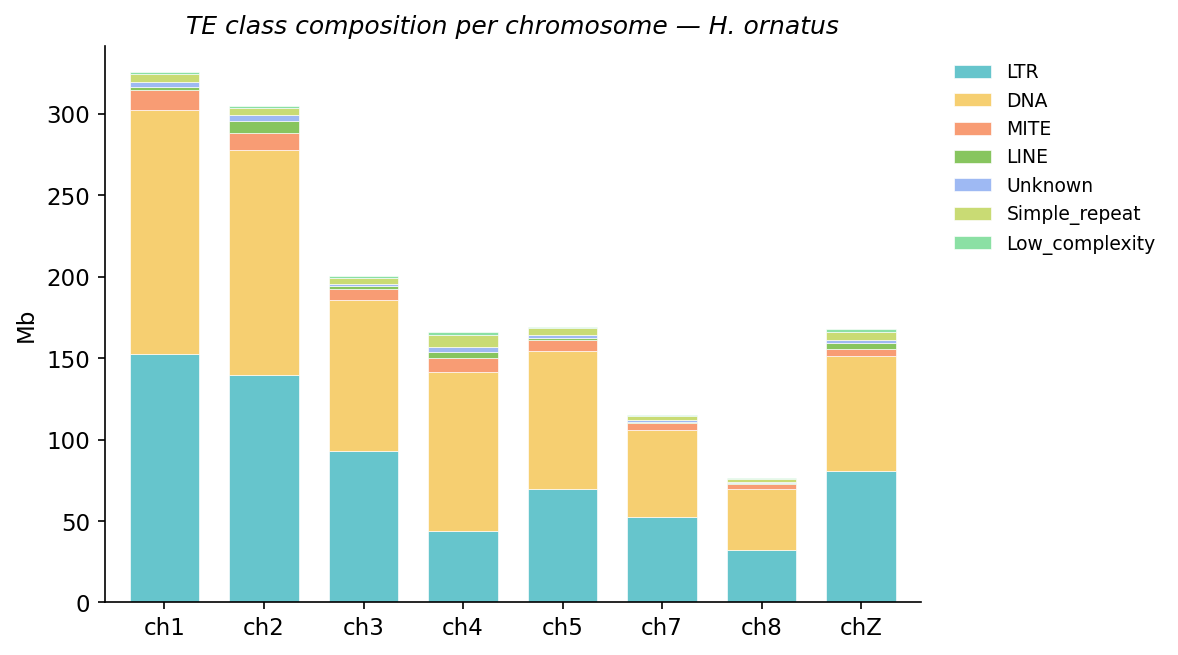

In [4]:
df = rm['horn']
df_chr = df[df['chrom'].isin(CHROMS)]

# bp per class per chrom
ct = df_chr.groupby(['chrom', 'class'])['bp'].sum().unstack(fill_value=0)
ct = ct.reindex(index=CHROMS, columns=CLASSES, fill_value=0) / 1e6  # Mb

fig, ax = plt.subplots(figsize=(8, 4.5))
ct.plot.bar(stacked=True, color=[COLORS[c] for c in ct.columns], ax=ax, width=0.7, edgecolor='white', linewidth=0.3)
ax.set_ylabel('Mb')
ax.set_xlabel('')
ax.set_title('TE class composition per chromosome — H. ornatus', style='italic', fontsize=12)
ax.legend(title='', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False, fontsize=9)
ax.set_xticklabels(CHROMS, rotation=0)
plt.tight_layout()
fig.savefig(OUTDIR / 'te_class_by_chrom_horn.png')
plt.show()

## 2. TE Family Composition — all species

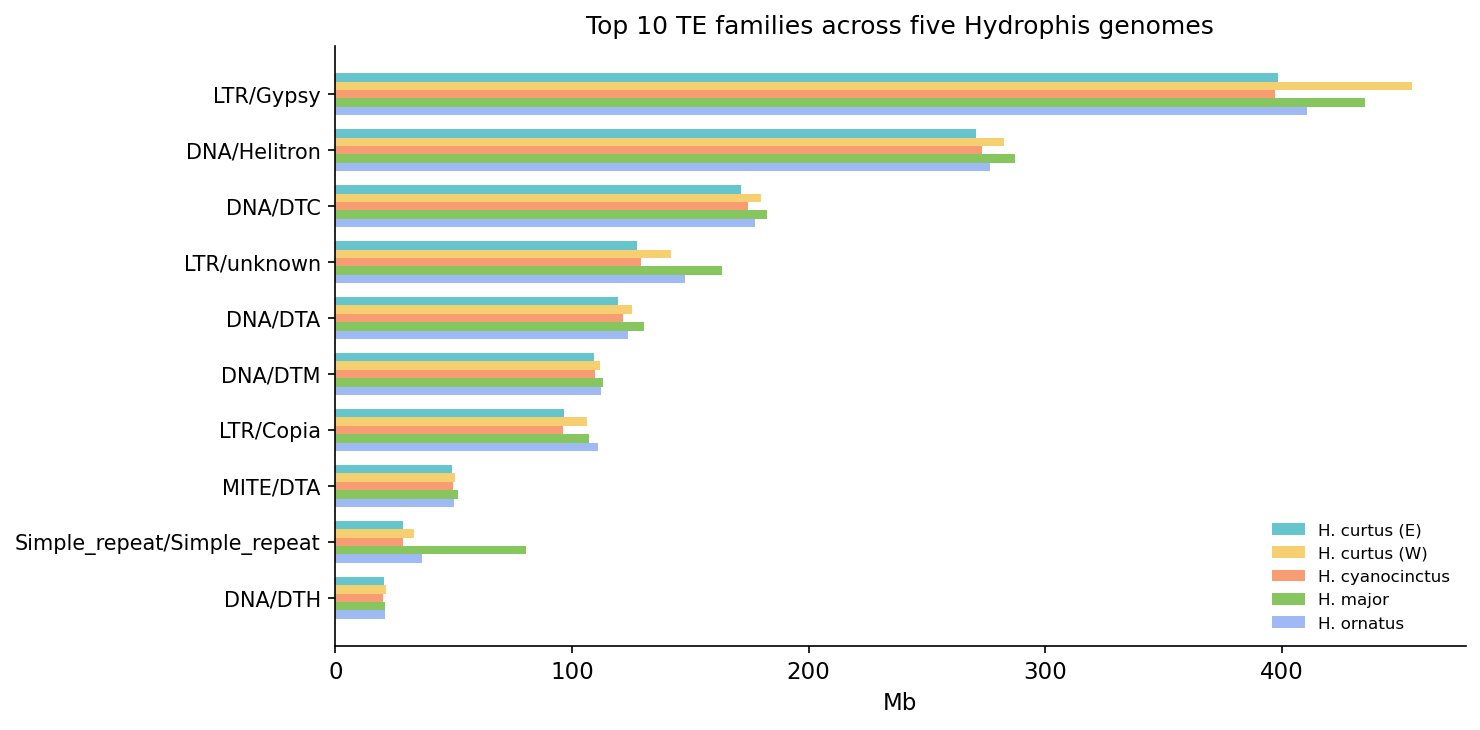

In [5]:
# top families (by total bp across all species)
fam_totals = defaultdict(int)
for sp in SPECIES:
    for fam, bp in rm[sp].groupby('family')['bp'].sum().items():
        fam_totals[fam] += bp

top_fams = sorted(fam_totals, key=fam_totals.get, reverse=True)[:10]

# build matrix
mat = pd.DataFrame(index=top_fams, columns=SP_LABELS, dtype=float)
for sp, label in zip(SPECIES, SP_LABELS):
    gb = rm[sp].groupby('family')['bp'].sum()
    for fam in top_fams:
        mat.loc[fam, label] = gb.get(fam, 0) / 1e6

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(top_fams))
w = 0.15
for i, label in enumerate(SP_LABELS):
    ax.barh(x + i * w, mat[label], height=w, label=label, color=SP_COLORS[i])

ax.set_yticks(x + w * 2)
ax.set_yticklabels(top_fams, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('Mb')
ax.set_title('Top 10 TE families across five Hydrophis genomes', fontsize=12)
ax.legend(frameon=False, fontsize=8, loc='lower right')
plt.tight_layout()
fig.savefig(OUTDIR / 'te_family_composition.png')
plt.show()


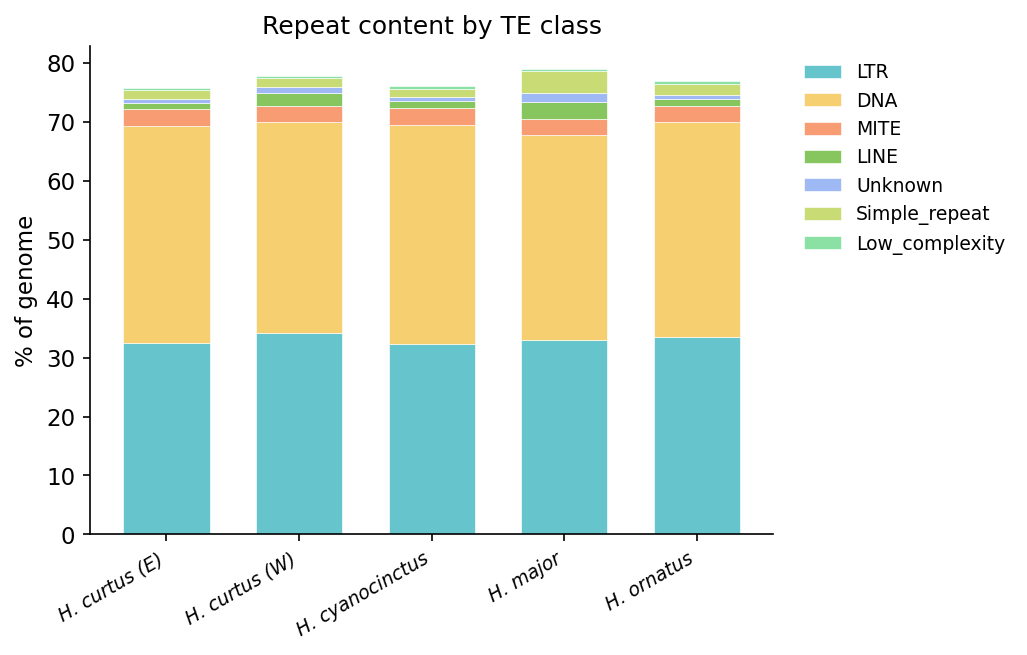

In [6]:
# class-level stacked bars across species
genome_bp = {'hcure': 1922533803, 'hcurw': 2058638819, 'hcy': 1927585190,
             'hmaj': 2150333220, 'horn': 1997787468}

class_pct = pd.DataFrame(index=SP_LABELS, columns=CLASSES, dtype=float)
for sp, label in zip(SPECIES, SP_LABELS):
    gb = rm[sp].groupby('class')['bp'].sum()
    for cls in CLASSES:
        class_pct.loc[label, cls] = gb.get(cls, 0) / genome_bp[sp] * 100

fig, ax = plt.subplots(figsize=(7, 4.5))
class_pct.plot.bar(stacked=True, color=[COLORS[c] for c in CLASSES], ax=ax, width=0.65,
                   edgecolor='white', linewidth=0.3)
ax.set_ylabel('% of genome')
ax.set_xlabel('')
ax.set_title('Repeat content by TE class', fontsize=12)
ax.legend(title='', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False, fontsize=9)
ax.set_xticklabels(SP_LABELS, rotation=30, ha='right', fontsize=9, style='italic')
plt.tight_layout()
fig.savefig(OUTDIR / 'te_class_stacked.png')
plt.show()

## 3. TE Age Distribution (Kimura divergence)

In [7]:
def parse_divsum(path):
    """Parse RM divsum → DataFrame with class, repeat, kimura."""
    rows = []
    with open(path) as f:
        for line in f:
            if line.startswith(('Class', '-----', 'Jukes', '====', 'File', 'Weight', '\n')):
                continue
            p = line.strip().split('\t')
            if len(p) < 5:
                continue
            try:
                cls = p[0].split('/')[0]
                rows.append({'class': cls, 'repeat': p[1],
                             'bp': int(p[2]), 'kimura': float(p[4])})
            except (ValueError, IndexError):
                continue
    return pd.DataFrame(rows)

divsum = {}
for sp in SPECIES:
    path = EDTA / f'edta_10-{sp}/repeatmasker_out/10-{sp}-final.renamed.fa.divsum'
    divsum[sp] = parse_divsum(path)
    print(f'{sp}: {len(divsum[sp])} families')

hcure: 11965 families
hcurw: 12129 families
hcy: 12102 families
hmaj: 11945 families
horn: 11839 families


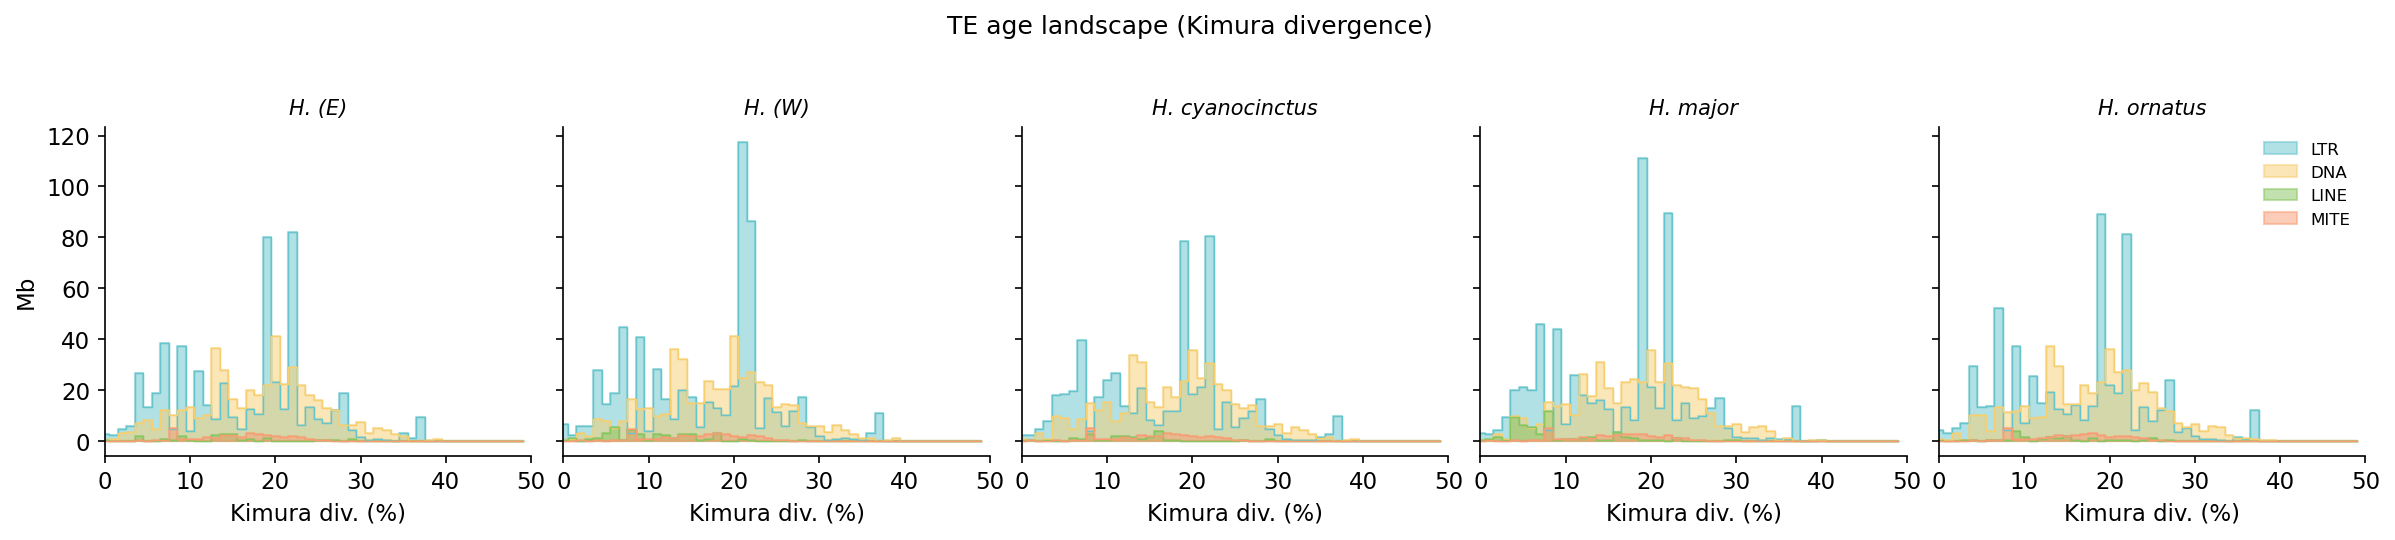

In [8]:
# Kimura divergence landscape — bp-weighted histogram per class
bins = np.arange(0, 51, 1)

fig, axes = plt.subplots(1, 5, figsize=(16, 3.5), sharey=True)
for ax, sp, label in zip(axes, SPECIES, SP_LABELS):
    ds = divsum[sp]
    for cls in ['LTR', 'DNA', 'LINE', 'MITE']:
        sub = ds[ds['class'] == cls]
        if sub.empty:
            continue
        # bp-weighted histogram
        hist, _ = np.histogram(sub['kimura'], bins=bins, weights=sub['bp'])
        ax.fill_between(bins[:-1], hist / 1e6, alpha=0.5, label=cls, color=COLORS[cls], step='mid')
        ax.step(bins[:-1], hist / 1e6, color=COLORS[cls], linewidth=0.7, where='mid')
    ax.set_title(f'H. {label.split()[-1]}', style='italic', fontsize=10)
    ax.set_xlabel('Kimura div. (%)')
    ax.set_xlim(0, 50)

axes[0].set_ylabel('Mb')
axes[-1].legend(frameon=False, fontsize=8, loc='upper right')
fig.suptitle('TE age landscape (Kimura divergence)', fontsize=12, y=1.02)
plt.tight_layout()
fig.savefig(OUTDIR / 'te_age_landscape.png')
plt.show()

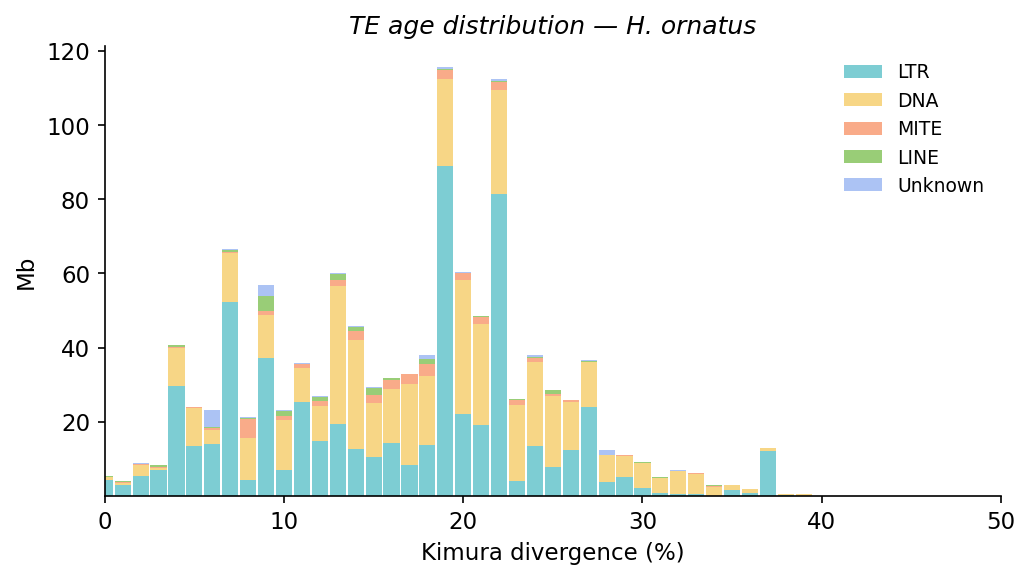

In [9]:
# single panel — horn only, all classes
fig, ax = plt.subplots(figsize=(7, 4))
ds = divsum['horn']
bottom = np.zeros(len(bins) - 1)
for cls in ['LTR', 'DNA', 'MITE', 'LINE', 'Unknown']:
    sub = ds[ds['class'] == cls]
    hist, _ = np.histogram(sub['kimura'], bins=bins, weights=sub['bp'])
    ax.bar(bins[:-1], hist / 1e6, bottom=bottom, width=0.9, color=COLORS[cls], label=cls, alpha=0.85)
    bottom += hist / 1e6

ax.set_xlabel('Kimura divergence (%)')
ax.set_ylabel('Mb')
ax.set_title('TE age distribution — H. ornatus', style='italic', fontsize=12)
ax.legend(frameon=False, fontsize=9)
ax.set_xlim(0, 50)
plt.tight_layout()
fig.savefig(OUTDIR / 'te_age_horn.png')
plt.show()

## 4. TEforest Insertion Genotyping